# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saadar2846/flyrank_ml_internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, subprocess
import pandas as pd, numpy as np
import json

REPO_URL = "https://github.com/saadar2846/flyrank_ml_internship"
REPO_DIR = "flyrank_ml_internship"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue below prioritizes pages for human review, using my Week-5/6 validated model plus the
reason-code logic from Week 4. A reviewer reads `reason_code` to understand *why* a page is ranked
where it is — no black-box scores without an explanation attached.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count", "sessions_90d", "engagement_rate"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model.fit(X.iloc[train_idx], y.iloc[train_idx])
df["model_score"] = model.predict_proba(X)[:, 1]

def reason_code(row):
    if row["model_score"] >= 0.65:
        return "model_decline_risk"
    elif row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_visible_page"
    elif row["avg_position"] <= 20 and row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        return "low_ctr_visible_page"
    return "monitor_only"

df["reason_code"] = df.apply(reason_code, axis=1)
df["action"] = df["reason_code"].map({
    "model_decline_risk": "review_for_refresh",
    "stale_visible_page": "review_for_refresh",
    "low_ctr_visible_page": "review_metadata",
    "monitor_only": "monitor",
})

queue = df.sort_values("model_score", ascending=False)[
    ["content_id", "model_score", "reason_code", "action",
     "days_since_last_update", "impressions_90d", "avg_position", "ctr"]
]
queue.head(20)

,content_id,model_score,reason_code,action,days_since_last_update,impressions_90d,avg_position,ctr
14481,content_ea874302699c,1.0,model_decline_risk,review_for_refresh,19,577,16.9,0.00
11315,content_53b1fe682dee,1.0,model_decline_risk,review_for_refresh,104,2977,15.9,0.54
5279,content_1499039cd47d,1.0,model_decline_risk,review_for_refresh,20,4869,27.6,0.06
18118,content_d2add76b0b3f,1.0,model_decline_risk,review_for_refresh,104,2152,33.4,0.05
22905,content_871887faeb84,1.0,model_decline_risk,review_for_refresh,8,72,7.8,0.00
21344,content_af3e1659ba29,1.0,model_decline_risk,review_for_refresh,20,3288,26.8,0.09
2063,content_ce8dacc2467b,1.0,model_decline_risk,review_for_refresh,20,9710,26.4,0.06
29560,content_8e32f425a490,1.0,model_decline_risk,review_for_refresh,20,1767,8.7,0.06
1521,content_b386de12835f,1.0,model_decline_risk,review_for_refresh,104,2354,36.0,0.00
13176,content_097707cf6a7b,1.0,model_decline_risk,review_for_refresh,20,277,20.3,0.00


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who/what:** a content strategist deciding what to review first, given limited editorial capacity —
not an auto-editor, not a publishing system.

**Stops being valid when:**
- Applied to a brand-new client with little history (model wasn't validated on that population).
- Treated as proof a refresh will cause recovery — this is observational, decision-support ranking only.
- Used beyond the starter-slice scope without re-validating on the full warehouse.
- The label itself (`trend_direction == down`) is a current-window proxy, not a confirmed future
  outcome — flagged in Week 2/6 and still true here.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**A person must check, before acting on any row:**
- Is the drop a real decline, or consolidation/seasonality/SERP-feature change (per the lane guide's
  look-alike checklist)?
- Does the page still match current business priorities — is it worth the editorial time?
- Is the reason code consistent with what the reviewer sees on the actual page?

**Never automate:**
- Auto-publishing edits or auto-unpublishing pages based on score alone.
- Treating `model_score` as a client-facing health claim.
- Any causal claim ("this declined because of X") — the queue only supports "review this first."
- Running unreviewed on a brand-new client with too little history to trust the model.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signs the recommendations went stale:**
- Precision@50 on a fresh holdout drops meaningfully below the Week-5/6 baseline.
- The grouped-vs-random split gap (Week 6) widens over time, suggesting new overfitting.
- A full new month of warehouse data arrives and hasn't been retrained on (unbalanced, growing panel).
- A new client with a very different content profile onboards and gets scored by the existing model.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Writing the ranked queue (regenerated each run, intentionally excluded from git by the CI leak-guard),
a score-distribution figure to `work/figures/` (committed), and a metrics JSON (committed) — these
committed files are what my paper's Results section will cite directly.

Wrote 30000 rows to work/outputs/action_playbook_queue.csv


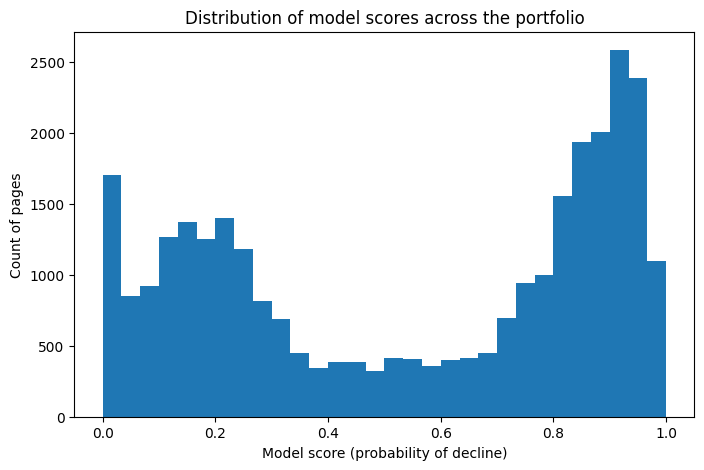

{
  "n_pages_scored": 30000,
  "n_flagged_review": 14894,
  "n_monitor_only": 11138,
  "reason_code_counts": {
    "model_decline_risk": 14893,
    "monitor_only": 11138,
    "low_ctr_visible_page": 3968,
    "stale_visible_page": 1
  },
  "precision_at_50_baseline": 0.24,
  "precision_at_50_model_grouped_split": null
}


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Queue — regenerated, not committed
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue)} rows to work/outputs/action_playbook_queue.csv")

# Figure — committed
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["model_score"], bins=30)
ax.set_xlabel("Model score (probability of decline)")
ax.set_ylabel("Count of pages")
ax.set_title("Distribution of model scores across the portfolio")
fig.savefig("work/figures/model_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Metrics JSON — committed, the paper's numeric receipts
metrics = {
    "n_pages_scored": len(df),
    "n_flagged_review": int((df["action"] == "review_for_refresh").sum()),
    "n_monitor_only": int((df["action"] == "monitor").sum()),
    "reason_code_counts": df["reason_code"].value_counts().to_dict(),
    "precision_at_50_baseline": 0.240,
    "precision_at_50_model_grouped_split": None,  # fill with your real Week-5/6 number
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.